In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, make_scorer

In [12]:
df = pd.read_csv("../Buoi3/du-lieu/training_set.csv")
df = df.dropna(subset=["van_ban_goc"])

X = df["van_ban_goc"]
y = df ["nhan"]

In [25]:
def mo_hinh():
    return make_pipeline(
        TfidfVectorizer(min_df=2),
        LogisticRegression(max_iter=1000, class_weight="balanced")
    )

In [14]:
f1 = lambda a, b: f1_score(a, b, average="macro", labels=[0,1], zero_division=0)
cham = make_scorer(f1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [15]:
train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator=mo_hinh(),
    X=X, y=y,
    train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv = skf,
    scoring=cham,
    n_jobs=1,
    random_state=0
)

In [16]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

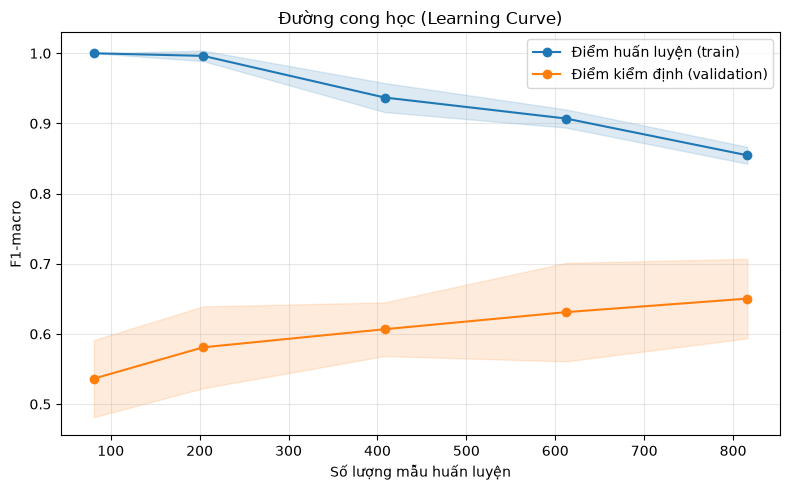

   train_size  train_f1_mean  val_f1_mean  khoang_cach
0          81       1.000000     0.536322     0.463678
1         204       0.996288     0.580944     0.415344
2         408       0.936947     0.606704     0.330243
3         612       0.907005     0.631062     0.275943
4         816       0.854600     0.650365     0.204235


In [24]:
plt.figure(figsize=(8, 5))

plt.plot(train_sizes_abs, train_mean, "o-", color="tab:blue", label="Điểm huấn luyện (train)")
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                  alpha=0.15, color="tab:blue")

plt.plot(train_sizes_abs, test_mean, "o-", color="tab:orange", label="Điểm kiểm định (validation)")
plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std,
                  alpha=0.15, color="tab:orange")

plt.xlabel("Số lượng mẫu huấn luyện")
plt.ylabel("F1-macro")
plt.title("Đường cong học (Learning Curve)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ket_qua = pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_f1_mean": train_mean,
    "val_f1_mean": test_mean,
    "khoang_cach": train_mean - test_mean,
})
print(ket_qua)